# RTU 2025–2026 Program Analysis

## Background
The Collaborative is one of Vermont's largest substance misuse prevention organizations, dedicated to empowering youth and families while fostering healthy, supportive communities.
One of their flagship initiatives is the Resilience Through Understanding (RTU) program which is a series of events designed for middle and high school students and their families. Through RTU, participants build community connections, learn about the risks of substance misuse, and earn incentives for participation.

Across five events, the program has reached over 360 youth-adult pairs at 10 local Vermont schools. We wanted to trace where the program holds its reach across the school year and where it breaks down.
RTU follow-up surveys capture responses from both youth participants and their caring adults, who attend events together as pairs. Throughout this analysis, participation counts refer to youth-adult pairs.


## Research question and motivation
**Where does RTU's reach hold across the program year, and where does it break down?**

Specifically:

1. How many youth-adult pairs participate at each of the five events?
2. Where in the program do the largest drops happen?
3. Are those drops uniform across schools, or are they possibly driven by specific schools or specific event formats?
4. What do the patterns suggest about program design and scalability? (do if time)

This matters because RTU's value depends on continuous buy in and participation. A pair that attends only the Kickoff has probably not gotten the full benefits of the program. Understanding where participants leave the program is the first step toward keeping more of them through to the end.

## 1. Setup and data loading

The dataset is an Excel workbook with one sheet per event (Kickoff, Event 2, Event 3, Event 4, Event 5). Each row is one survey response from a youth-adult pair.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Notebook-wide plot styling
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 12

# Color palette (consistent across all figures)
PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
BLUE   = '#378ADD'
AMBER  = '#BA7517'
GRAY   = '#888780'
RED    = '#E24B4A'

In [11]:
# Load the workbook. file lives at the colab notebook's working directory after upload.
FILE_PATH = 'all_RTU_data.xlsx'
sheets = pd.read_excel(FILE_PATH, sheet_name=None)

# Standardize sheet ordering and give each event a clean label
EVENT_ORDER = ['Kickoff Follow Up', 'Event 2 Follow Up', 'Event 3 Follow Up',
               'Event 4 Follow Up', 'Event 5 Follow up']
EVENT_LABELS = ['Kickoff', 'Event 2', 'Event 3', 'Event 4', 'Event 5']

for name in EVENT_ORDER:
    df = sheets[name]
    print(f'{name:25s}  rows: {len(df):4d}  cols: {df.shape[1]}')

Kickoff Follow Up          rows:  364  cols: 46
Event 2 Follow Up          rows:  390  cols: 16
Event 3 Follow Up          rows:  342  cols: 21
Event 4 Follow Up          rows:  193  cols: 21
Event 5 Follow up          rows:   56  cols: 28


In [12]:
import os
print(f"Current working directory: {os.getcwd()}")
print("Files in current directory:")
for dirname, _, filenames in os.walk(os.getcwd()):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Current working directory: /content
Files in current directory:
/content/all_RTU_data.xlsx
/content/.config/active_config
/content/.config/.last_update_check.json
/content/.config/.last_survey_prompt.yaml
/content/.config/gce
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/default_configs.db
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/configurations/config_default
/content/.config/logs/2026.04.16/13.28.21.827521.log
/content/.config/logs/2026.04.16/13.27.28.140888.log
/content/.config/logs/2026.04.16/13.27.53.684484.log
/content/.config/logs/2026.04.16/13.28.06.952902.log
/content/.config/logs/2026.04.16/13.28.05.189231.log
/content/.config/logs/2026.04.16/13.28.22.950479.log
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_d

## 2. Data exploration and cleaning

Each sheet has a different column layout because each event asked different follow-up questions. The two columns we care about for participation analysis are `School` and `Grade Level` which appear in all five sheets.

Steps:

1. Drop fully blank rows (Excel artifact rows with no data).
2. Verify that `School` is non-null for actual responses (a row with no school is unusable for school-level analysis).
3. Standardize school names so we don't double-count typos.

In [13]:
# Show a representative slice of the Kickoff sheet
kickoff = sheets['Kickoff Follow Up']
print('Kickoff columns:')
for c in kickoff.columns:
    print(f'  - {c}')
print()
kickoff.head(3)

Kickoff columns:
  - School
  - Grade Level
  - Which Kickoff event did you attend?
  - Did you feel safe and comfortable at the event?
  - Ed Gerety said that, "Words create your reality." What do you think he meant by that? How can you use positive language to reach your goals?
  - Check a box for each type of person you feel you have in your life. One person can count for more than one category!
  - What thoughts came up for you as you looked through those categories and thought about people who play some of those roles in your own life?
  - What did you learn from this event?
  - How will you apply what you learned to your everyday life?
  - Did you feel safe and comfortable at the event? 2
  - Ed Gerety said that, "Words create your reality." What do you think he meant by that? How can you use positive language to reach your goals? 2
  - Check a box for each type of person you feel you have in your life. One person can count for more than one category! 2
  - What thoughts came up 

,School,Grade Level,Which Kickoff event did you attend?,Did you feel safe and comfortable at the event?,"Ed Gerety said that, ""Words create your reality."" What do you think he meant by that? How can you use positive language to reach your goals?",Check a box for each type of person you feel you have in your life. One person can count for more than one category!,What thoughts came up for you as you looked through those categories and thought about people who play some of those roles in your own life?,What did you learn from this event?,How will you apply what you learned to your everyday life?,Did you feel safe and comfortable at the event? 2,...,What thoughts came up for you as you looked through those categories and thought about people who play some of those roles in your own life? 6,What did you learn from this event? 6,How will you apply what you learned to your everyday life? 6,Where might you be able to go to try and make new connections to be able to check even more of those boxes? 2,(Optional) Additional comments and feedback 2,How can playing games or doing fun things together help prevent substance misuse?,"In at least 100 words, describe the information in the resources you reviewed and what it says about social connection and substance misuse prevention. Be as thoughtful as you can and demonstrate your understanding of the information you found.","In at least 100 words, discuss how you might apply this information to your everyday life, both individually and together. Be as thoughtful as you can and demonstrate your understanding of the information you found.",(Optional) Anything else that you would like to share?,"Please select one of the following assignments to complete together (participant and caring adult) and submit via email to rtu@thecollaborative.us. \n\nThis activity is meant to promote connection and to be a fun way to engage with one another. \n\nRequired: In the message, include a few sentences reflecting on how it felt to complete this portion of the assignment together."
0,Leland & Gray,11th,"September 22, Ed Gerety, Leland & Gray",5.0,If you surround yourself with positive people ...,A confidant - someone you can talk to about an...,I'm very grateful for the people who I surroun...,Writing down goals can make dreams come true. ...,I will always talk with positive words about m...,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Leland & Gray,6th,"September 22, Ed Gerety, Leland & Gray",5.0,What you say or believe dictates your future,A confidant - someone you can talk to about an...,I am loved,Words carry meaning,The group of people who you surround yourself ...,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Leland & Gray,7th,"September 22, Ed Gerety, Leland & Gray",5.0,I believe that what Ed meant by saying “Words ...,A confidant - someone you can talk to about an...,I’m a very lucky person to have all these wond...,I learned from this event that every single on...,I will apply what I learned to my everyday lif...,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Check for missing values in the two columns we'll use
for name in EVENT_ORDER:
    df = sheets[name]
    n_total = len(df)
    n_blank = df.isna().all(axis=1).sum()
    n_no_school = df['School'].isna().sum()
    print(f'{name:25s}  total: {n_total:4d}  fully-blank: {n_blank:2d}  missing School: {n_no_school:2d}')

Kickoff Follow Up          total:  364  fully-blank:  0  missing School:  0
Event 2 Follow Up          total:  390  fully-blank:  0  missing School:  0
Event 3 Follow Up          total:  342  fully-blank:  0  missing School:  0
Event 4 Follow Up          total:  193  fully-blank:  0  missing School:  0
Event 5 Follow up          total:   56  fully-blank:  0  missing School:  0


In [15]:
# Inspect unique school names to catch any inconsistent labels
all_schools = pd.concat([df[['School']] for df in sheets.values()])['School'].dropna()
print('Unique school labels across all sheets:')
print(all_schools.value_counts())

Unique school labels across all sheets:
School
BBA                          387
Leland & Gray                310
Long Trail School            219
BBA International Student    129
Flood Brook School            92
MEMS                          61
Arlington Memorial            61
Dorset School                 35
Maple Street School           33
Homeschool                    16
Stratton Mountain School       2
Name: count, dtype: int64


**Cleaning decisions:**

- Drop rows where `School` is null. These are unusable for school-level analysis and represent <1% of any sheet.
- The label `BBA International Student` appears in Kickoff–Event 4 but not Event 5. Per the team's outline, we treat BBA International as its own school cohort (consistent with how the program tracks them).
- All other school names are already consistent (no typo variants found).

In [16]:
# Apply the cleaning step to every sheet
clean = {name: df.dropna(subset=['School']).copy() for name, df in sheets.items()}

# Confirm the cleaned counts
for name in EVENT_ORDER:
    print(f'{name:25s}  cleaned rows: {len(clean[name])}')

Kickoff Follow Up          cleaned rows: 364
Event 2 Follow Up          cleaned rows: 390
Event 3 Follow Up          cleaned rows: 342
Event 4 Follow Up          cleaned rows: 193
Event 5 Follow up          cleaned rows: 56


## 3. Analysis

### 3.1 Overall participation funnel

Count youth-adult pairs (one row = one pair) at each of the five events.

In [17]:
# Total responses per event
event_totals = pd.Series(
    {label: len(clean[name]) for name, label in zip(EVENT_ORDER, EVENT_LABELS)}
)
print(event_totals)
print()

# Compute event-to-event change
kickoff_n = event_totals['Kickoff']
final_n = event_totals['Event 5']
overall_loss_pct = (kickoff_n - final_n) / kickoff_n * 100
print(f'Total responses across all events: {event_totals.sum()}')
print(f'Loss from Kickoff to Event 5: {kickoff_n - final_n} pairs ({overall_loss_pct:.0f}%)')
print()
print('Pairs lost between consecutive events:')
for i in range(1, len(EVENT_LABELS)):
    prev = event_totals.iloc[i-1]
    curr = event_totals.iloc[i]
    print(f'  {EVENT_LABELS[i-1]} -> {EVENT_LABELS[i]}: {curr - prev:+d}')

Kickoff    364
Event 2    390
Event 3    342
Event 4    193
Event 5     56
dtype: int64

Total responses across all events: 1345
Loss from Kickoff to Event 5: 308 pairs (85%)

Pairs lost between consecutive events:
  Kickoff -> Event 2: +26
  Event 2 -> Event 3: -48
  Event 3 -> Event 4: -149
  Event 4 -> Event 5: -137


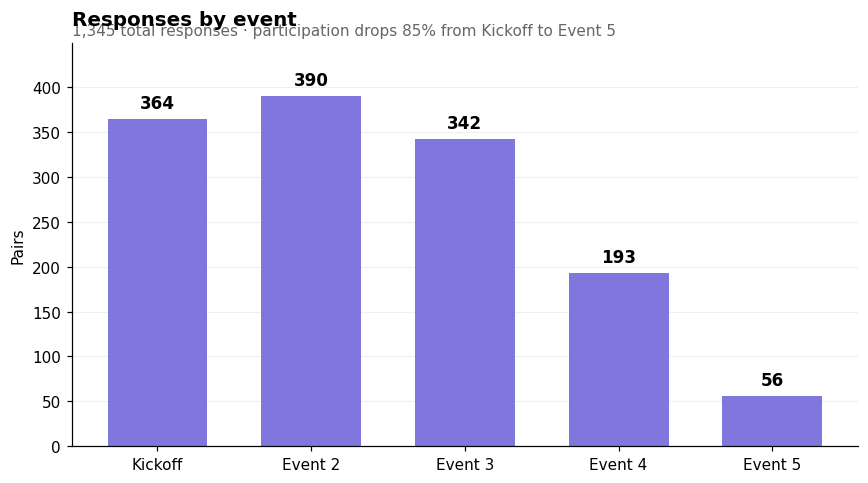

In [18]:
# FIGURE 1 — Participation funnel
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(event_totals.index, event_totals.values, color=PURPLE, width=0.65)

# Annotate each bar with its value
for bar, val in zip(bars, event_totals.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 8, f'{val}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Responses by event', loc='left')
ax.text(0, 1.02, f'{event_totals.sum():,} total responses · participation drops {overall_loss_pct:.0f}% from Kickoff to Event 5',
        transform=ax.transAxes, fontsize=10, color='#666')
ax.set_ylabel('Pairs')
ax.set_ylim(0, event_totals.max() * 1.15)
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Observation:** the program holds steady through the first three events, then drops sharply twice in a row. We treat these as two distinct cliffs and analyze them separately.

### 3.2 Building the school × event matrix

To analyze where the drops are concentrated, we build a matrix where rows are schools and columns are events.

In [19]:
# Build school × event count matrix
matrix_records = {}
for name, label in zip(EVENT_ORDER, EVENT_LABELS):
    matrix_records[label] = clean[name]['School'].value_counts()

matrix = pd.DataFrame(matrix_records).fillna(0).astype(int)
matrix = matrix.sort_values('Kickoff', ascending=False)
matrix['Total'] = matrix.sum(axis=1)
matrix

,Kickoff,Event 2,Event 3,Event 4,Event 5,Total
School,,,,,,
BBA,113,114,98,42,20,387
Leland & Gray,69,93,71,54,23,310
Long Trail School,58,60,55,33,13,219
BBA International Student,35,36,32,26,0,129
Flood Brook School,25,25,29,13,0,92
Arlington Memorial,19,17,16,9,0,61
MEMS,18,17,15,11,0,61
Dorset School,10,11,11,3,0,35
Maple Street School,9,12,11,1,0,33


### 3.3 Event 3 to Event 4

The single largest drop in the program is between Event 3 (342 pairs) and Event 4 (193 pairs) — a loss of 149 pairs in one transition. We check whether this is concentrated in one school (which would point to a school-specific cause) or spread across all schools (which would point to a structural cause).

In [20]:
# Per-school drop from Event 3 to Event 4
drop_3_to_4 = (matrix['Event 4'] - matrix['Event 3']).sort_values()
print('Per-school change Event 3 -> Event 4:')
print(drop_3_to_4)

Per-school change Event 3 -> Event 4:
School
BBA                         -56
Long Trail School           -22
Leland & Gray               -17
Flood Brook School          -16
Maple Street School         -10
Dorset School                -8
Arlington Memorial           -7
BBA International Student    -6
MEMS                         -4
Homeschool                   -3
Stratton Mountain School      0
dtype: int64


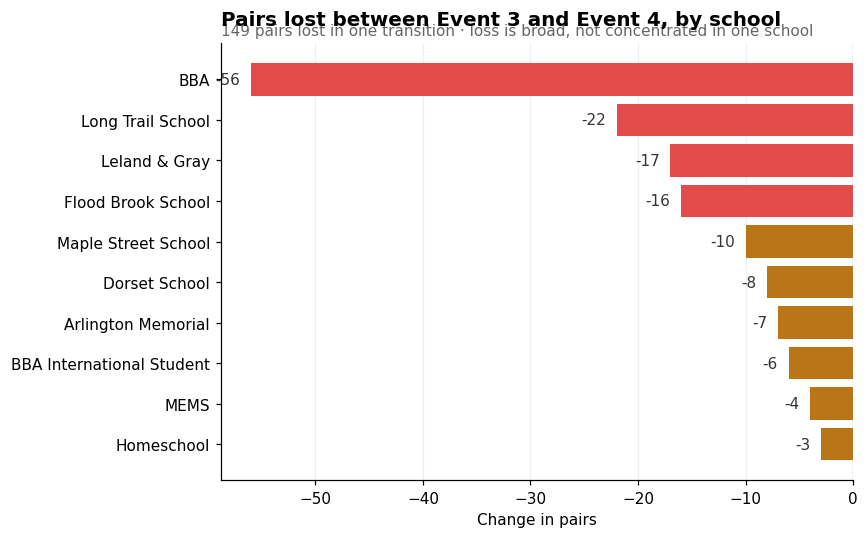

In [21]:
# Visualize the per-school drop
fig, ax = plt.subplots(figsize=(8, 5))
schools_drop = drop_3_to_4[drop_3_to_4 < 0]  # only schools that lost pairs
colors = [RED if v < -10 else AMBER for v in schools_drop.values]
bars = ax.barh(schools_drop.index, schools_drop.values, color=colors)

for bar, val in zip(bars, schools_drop.values):
    ax.text(val - 1, bar.get_y() + bar.get_height()/2, f'{val:+d}',
            va='center', ha='right', fontsize=10, color='#333')

ax.set_title('Pairs lost between Event 3 and Event 4, by school', loc='left')
ax.text(0, 1.02, '149 pairs lost in one transition · loss is broad, not concentrated in one school',
        transform=ax.transAxes, fontsize=10, color='#666')
ax.set_xlabel('Change in pairs')
ax.axvline(0, color='#999', linewidth=0.8)
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**every major school loses pairs.** When a decline shows up across the board at the same moment, the cause is usually structural rather than school-specific. The next thing to check is what changed about the event format itself.

Event 3 and Event 4 used different formats. Event 3 had one dominant format (an in-person event hosted by school or community reps). Event 4 fragmented across multiple site-specific options.

In [22]:
# Event 3 — how participants earned credit
event3_format = clean['Event 3 Follow Up']['How did you earn credit for Event 3?'].value_counts()
print('Event 3 formats:')
print(event3_format)
print(f'\nTop format share: {event3_format.iloc[0] / event3_format.sum() * 100:.0f}% of all Event 3 participation')

Event 3 formats:
How did you earn credit for Event 3?
In-person event hosted by your rep or another school- or community-based rep    266
In-person event hosted by The Collaborative                                      29
Makeup Assignment                                                                20
Community Service - Food Cupboard                                                19
Virtual event hosted by The Collaborative                                         8
Name: count, dtype: int64

Top format share: 78% of all Event 3 participation


In [23]:
# Event 4 — which Dialogue Night session participants attended
event4_sites = clean['Event 4 Follow Up']['Which Dialogue Night event did you attend?'].value_counts()
print('Event 4 site-specific sessions:')
print(event4_sites)
print(f'\nLargest single Event 4 session: {event4_sites.iloc[0]} pairs')
print(f'Number of distinct Event 4 sessions: {len(event4_sites)}')

Event 4 site-specific sessions:
Which Dialogue Night event did you attend?
January 20, Leland & Gray                    50
January 14, BBA Mountain Campus              45
January 15, Manchester Community Library     24
January 21, Maple Street School              20
January 28, Winhall Community Arts Center    15
Online Makeup Assignment                     14
January 23, Broomball at Riley Rink          12
January 16, BBA Yoga Studio                   6
February 12, Manchester Community Library     5
February 4, Bennington Theater                2
Name: count, dtype: int64

Largest single Event 4 session: 50 pairs
Number of distinct Event 4 sessions: 10


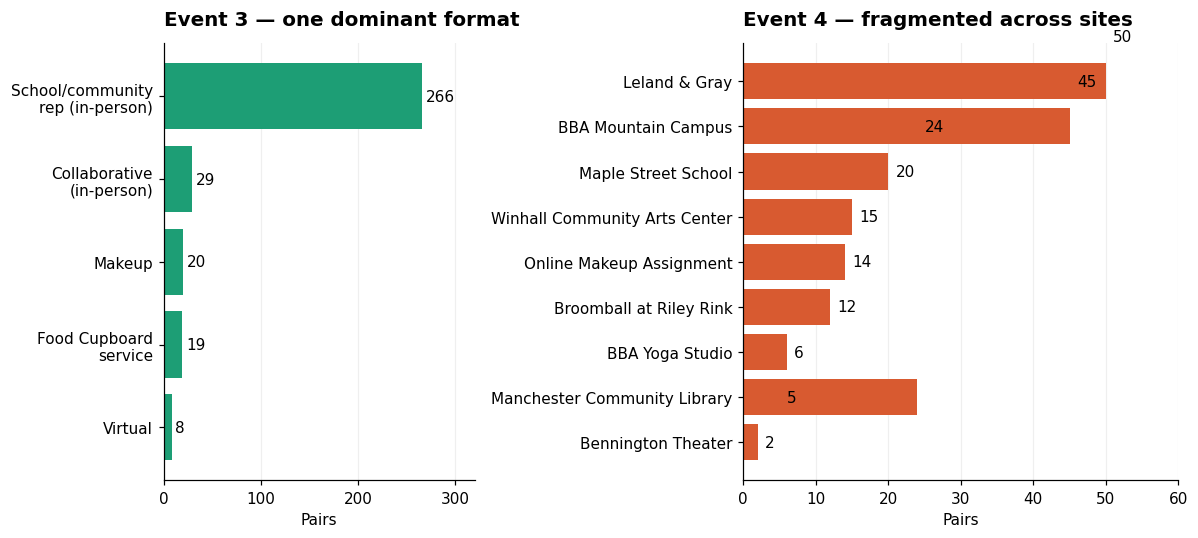

In [24]:
# Visualize the format contrast: Event 3 (one dominant format) vs Event 4 (fragmented)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [1, 1.4]})

# Event 3 — collapse to short labels
e3_labels = ['School/community\nrep (in-person)', 'Collaborative\n(in-person)', 'Makeup', 'Food Cupboard\nservice', 'Virtual']
ax1.barh(e3_labels[::-1], event3_format.values[::-1], color=TEAL)
for i, v in enumerate(event3_format.values[::-1]):
    ax1.text(v + 4, i, str(v), va='center', fontsize=10)
ax1.set_title('Event 3 — one dominant format', loc='left')
ax1.set_xlabel('Pairs')
ax1.set_xlim(0, 320)
ax1.grid(axis='x', alpha=0.2)
ax1.set_axisbelow(True)

# Event 4 — short site labels
e4_short = [s.split(',', 1)[1].strip() if ',' in s else s for s in event4_sites.index]
ax2.barh(e4_short[::-1], event4_sites.values[::-1], color=CORAL)
for i, v in enumerate(event4_sites.values[::-1]):
    ax2.text(v + 1, i, str(v), va='center', fontsize=10)
ax2.set_title('Event 4 — fragmented across sites', loc='left')
ax2.set_xlabel('Pairs')
ax2.set_xlim(0, 60)
ax2.grid(axis='x', alpha=0.2)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Format check:** at Event 3, one in-person format gathered 78% of all participation. At Event 4, the largest single session drew only 50 pairs — smaller than every Event 3 format except virtual.

We can see the consequence at the school level. Take BBA: 98 pairs at Event 3, 68 remaining at Event 4 — but only 11 of those went to the BBA-specific session. The pairs didn't all migrate to other Event 4 sessions; they thinned out across the program.

In [25]:
# BBA-specific check — how many BBA pairs attended each Event 4 site?
bba_e4 = clean['Event 4 Follow Up']
bba_e4 = bba_e4[bba_e4['School'] == 'BBA']
print('Where BBA pairs went at Event 4:')
print(bba_e4['Which Dialogue Night event did you attend?'].value_counts())

Where BBA pairs went at Event 4:
Which Dialogue Night event did you attend?
January 14, BBA Mountain Campus              9
January 15, Manchester Community Library     7
Online Makeup Assignment                     7
January 21, Maple Street School              6
January 23, Broomball at Riley Rink          6
January 28, Winhall Community Arts Center    3
January 16, BBA Yoga Studio                  2
February 12, Manchester Community Library    2
Name: count, dtype: int64


### 3.4 Event 4 to Event 5

The second cliff is a different shape. Between Event 4 (193 pairs) and Event 5 (56 pairs), 137 more pairs disappear. But this time, the loss is concentrated by school: only 3 of the 10 schools have any Event 5 responses at all.

In [26]:
# Schools with zero Event 5 responses
zero_e5 = matrix[matrix['Event 5'] == 0].index.tolist()
made_it = matrix[matrix['Event 5'] > 0].index.tolist()
print(f'Schools that reached Event 5 ({len(made_it)}): {made_it}')
print(f'Schools with zero Event 5 ({len(zero_e5)}): {zero_e5}')

Schools that reached Event 5 (3): ['BBA', 'Leland & Gray', 'Long Trail School']
Schools with zero Event 5 (8): ['BBA International Student', 'Flood Brook School', 'Arlington Memorial', 'MEMS', 'Dorset School', 'Maple Street School', 'Homeschool', 'Stratton Mountain School']


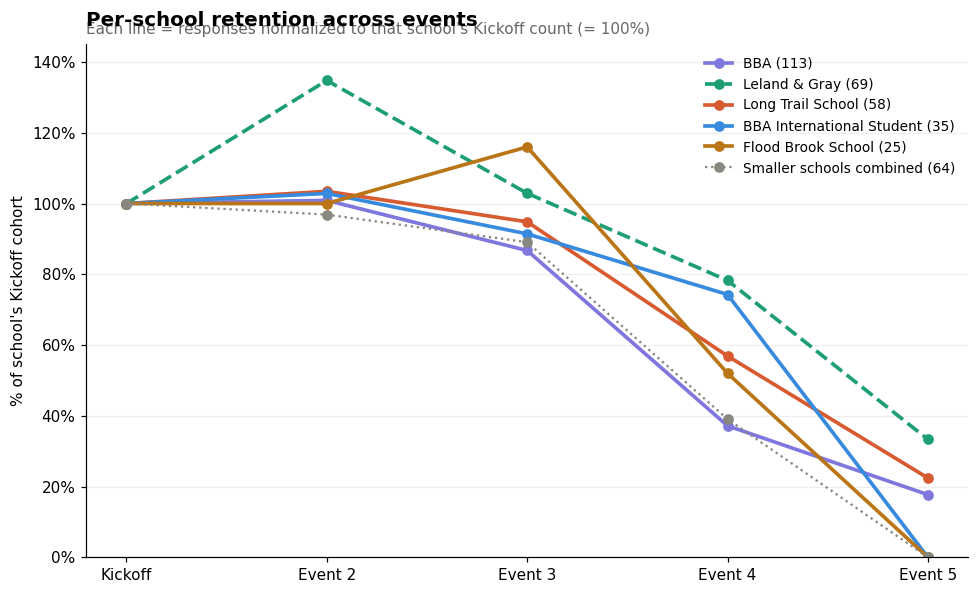

In [27]:
# FIGURE 2 — School survival slope graph
# Normalize each school's participation to its own Kickoff count (= 100%)
TOP_N = 5  # Show the largest schools individually; aggregate the rest
top_schools = matrix.head(TOP_N).index.tolist()
small_schools = matrix.iloc[TOP_N:].index.tolist()

def pct_curve(school):
    base = matrix.loc[school, 'Kickoff']
    if base == 0:
        return None
    return [matrix.loc[school, ev] / base * 100 for ev in EVENT_LABELS]

# Aggregate small schools into a combined curve
small_totals = matrix.loc[small_schools, EVENT_LABELS].sum()
small_curve = [v / small_totals['Kickoff'] * 100 for v in small_totals.values]

fig, ax = plt.subplots(figsize=(9, 5.5))
school_colors = [PURPLE, TEAL, CORAL, BLUE, AMBER]
for school, color in zip(top_schools, school_colors):
    curve = pct_curve(school)
    n = matrix.loc[school, 'Kickoff']
    linestyle = '--' if school == 'Leland & Gray' else '-'
    ax.plot(EVENT_LABELS, curve, marker='o', color=color, linewidth=2.4,
            linestyle=linestyle, label=f'{school} ({n})')
ax.plot(EVENT_LABELS, small_curve, marker='o', color=GRAY, linewidth=1.5,
        linestyle=':', label=f'Smaller schools combined ({int(small_totals["Kickoff"])})')

ax.set_title('Per-school retention across events', loc='left')
ax.text(0, 1.02, 'Each line = responses normalized to that school\'s Kickoff count (= 100%)',
        transform=ax.transAxes, fontsize=10, color='#666')
ax.set_ylabel('% of school\'s Kickoff cohort')
ax.set_ylim(0, 145)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v)}%'))
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
ax.legend(loc='upper right', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

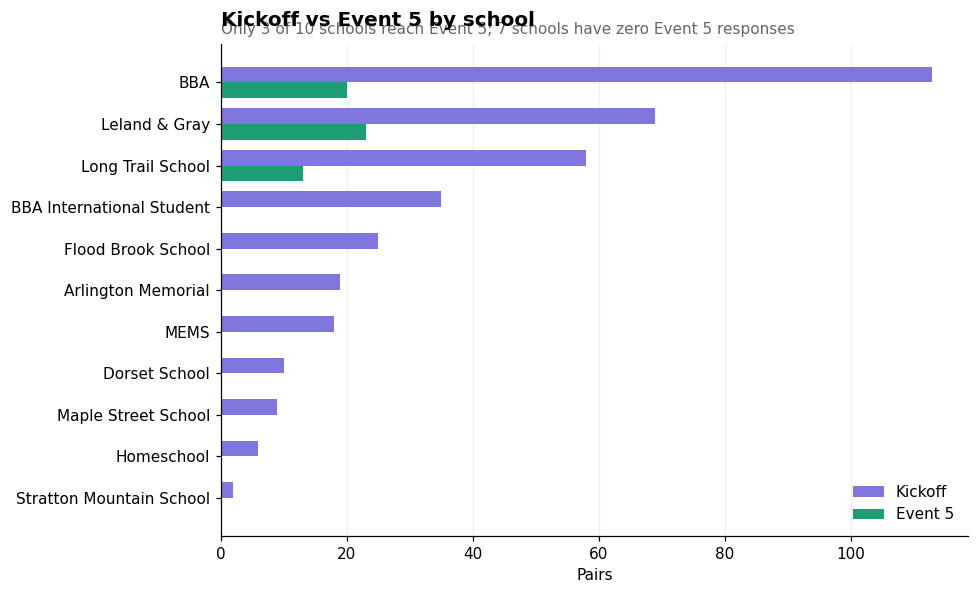

In [28]:
# FIGURE 3 — Kickoff vs Event 5, absolute counts
fig, ax = plt.subplots(figsize=(9, 5.5))
schools_sorted = matrix.index.tolist()
y_pos = np.arange(len(schools_sorted))
bar_h = 0.38

ax.barh(y_pos - bar_h/2, matrix['Kickoff'].values, height=bar_h, color=PURPLE, label='Kickoff')
ax.barh(y_pos + bar_h/2, matrix['Event 5'].values, height=bar_h, color=TEAL, label='Event 5')

ax.set_yticks(y_pos)
ax.set_yticklabels(schools_sorted)
ax.invert_yaxis()
ax.set_title('Kickoff vs Event 5 by school', loc='left')
ax.text(0, 1.02, 'Only 3 of 10 schools reach Event 5; 7 schools have zero Event 5 responses',
        transform=ax.transAxes, fontsize=10, color='#666')
ax.set_xlabel('Pairs')
ax.legend(loc='lower right', frameon=False)
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Pattern check.** The Event 4 → Event 5 loss isn't 137 pairs scattered across all schools — it's entire school cohorts disappearing at once. This is qualitatively different from what we saw at the Event 3 → Event 4 cliff.

Two cliffs, two different mechanisms:

- **Cliff 1 (Event 3 → 4)** is a **format problem.** When the program lost its shared center of gravity, pairs from every school thinned out.
- **Cliff 2 (Event 4 → 5)** is a **school-level problem.** Whole cohorts went to zero. The data can't tell us definitively why, but the pattern is consistent with school-side factors: staff capacity to organize, scheduling conflicts, and whether there's a local champion to host or coordinate a final session.

### 3.5 Putting both cliffs in one view

We can summarize both findings with a single chart that color-codes each school by where its participation went to zero.

In [29]:
# Determine the last event each school participated in
def last_event(school):
    for ev in reversed(EVENT_LABELS):
        if matrix.loc[school, ev] > 0:
            return ev
    return 'None'

last_event_map = {s: last_event(s) for s in matrix.index}
for s, ev in last_event_map.items():
    print(f'  {s:30s} last seen at: {ev}')

  BBA                            last seen at: Event 5
  Leland & Gray                  last seen at: Event 5
  Long Trail School              last seen at: Event 5
  BBA International Student      last seen at: Event 4
  Flood Brook School             last seen at: Event 4
  Arlington Memorial             last seen at: Event 4
  MEMS                           last seen at: Event 4
  Dorset School                  last seen at: Event 4
  Maple Street School            last seen at: Event 4
  Homeschool                     last seen at: Event 4
  Stratton Mountain School       last seen at: Kickoff


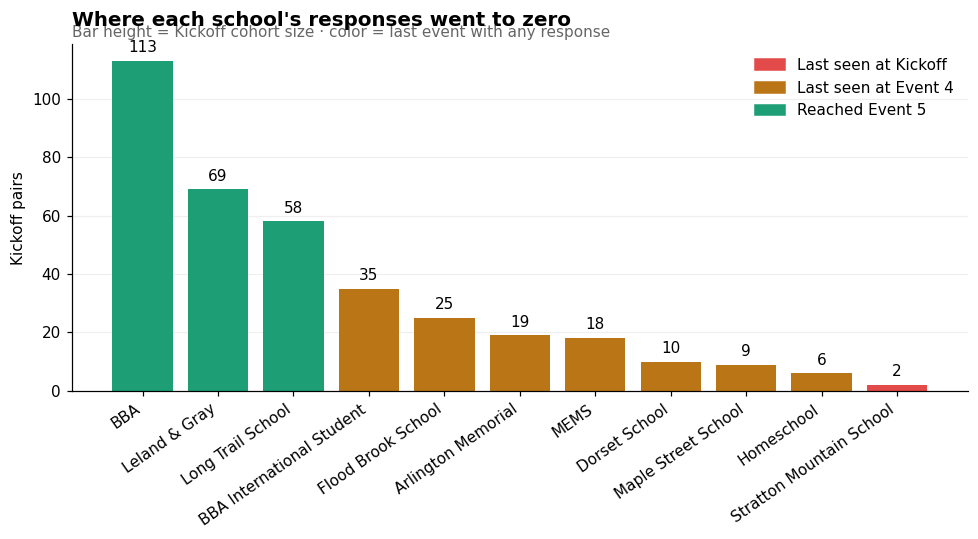

In [30]:
# FIGURE 4 — Where each school's participation went to zero
stage_colors = {'Kickoff': RED, 'Event 2': RED, 'Event 3': AMBER, 'Event 4': AMBER, 'Event 5': TEAL}
schools_sorted = matrix.index.tolist()
colors_for_bars = [stage_colors[last_event_map[s]] for s in schools_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(schools_sorted, matrix['Kickoff'].values, color=colors_for_bars)
for bar, val in zip(bars, matrix['Kickoff'].values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, str(val),
            ha='center', va='bottom', fontsize=10)

ax.set_title('Where each school\'s responses went to zero', loc='left')
ax.text(0, 1.02, 'Bar height = Kickoff cohort size · color = last event with any response',
        transform=ax.transAxes, fontsize=10, color='#666')
ax.set_ylabel('Kickoff pairs')
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=RED, label='Last seen at Kickoff'),
    Patch(color=AMBER, label='Last seen at Event 4'),
    Patch(color=TEAL, label='Reached Event 5'),
], loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

## 4. Interpretation and narrative

### What we found

RTU's reach is real at the start: more than 360 youth-adult pairs across 10 schools attended the Kickoff. Participation holds steady through Event 3 (342 pairs), but then drops sharply twice in a row — losing 149 pairs between Events 3 and 4, and another 137 between Events 4 and 5. By the end, 85% of the families that started were gone.

The two cliffs are not the same shape, and they don't have the same cause:

- The **first cliff** (Event 3 → 4) is **broad and structural.** Every major school lost pairs. Event 3 had one dominant in-person format that drew 78% of participation. Event 4 fragmented across eight site-specific sessions, the largest of which drew only 50 pairs. BBA had 68 pairs remaining at Event 4 but only 11 attended the BBA-specific session. When the program lost its shared center of gravity, it lost participants — across the board.
- The **second cliff** (Event 4 → 5) is **narrow and school-level.** Only 3 of the 10 schools — BBA, Leland & Gray, and Long Trail — had any Event 5 responses. Seven schools went to zero in one event. This isn't student-by-student dropout; it's entire school cohorts disappearing at once. The data can't tell us definitively why, but the pattern is consistent with school-side capacity: staff to organize a final session, scheduling room in the school calendar, and a local champion holding it together.

### What it means for the program

The story isn't that RTU is failing. The reach at Kickoff is significant, the safety and comfort scores are high throughout, and the schools that complete the program show strong wellness outcomes. The story is that RTU's two main scalability mechanisms — a unified mid-year format and school-level relationships — are showing stress in different ways.

Two takeaways for program design:

1. **Keep mid-year events structurally unified.** Fragmentation correlates with attrition. If Event 4 needs to be site-specific for logistical reasons, the program should plan for and absorb the resulting drop, or invest in cross-site recruitment to keep momentum.
2. **Invest in school-level relationships.** The three schools that reached Event 5 likely shared something the others didn't — a person at the school making the final event possible. Whether that's a teacher, counselor, or community liaison, that role appears to be the difference between completing the program and disappearing.

The participants who made it to Event 5 stayed because someone at their school made it possible.

### Limitations

- The data captures survey responses, not raw attendance. A pair that attended an event but didn't fill out the follow-up survey is invisible to this analysis. Response rate likely varies by event and by school.
- We treat each row as one youth-adult pair. We don't have a stable pair ID across events, so we can't track individual pairs longitudinally — only school-level cohorts.
- The Event 2 count exceeds Kickoff for several schools (e.g., Leland & Gray: 69 → 93). This likely reflects late joiners or makeup activity rather than a true increase in unique pairs. Our retention curves show this honestly rather than capping at 100%.
- The hypothesis that school-level capacity drives the second cliff is suggestive, not proven. Confirming it would require interviews or attendance data from school staff.